In [421]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import os


In [ ]:
input_path = '/home/timok/CLionProjects/PSOMAB/cmake-build-debug/'

In [422]:
visited = pd.DataFrame()

In [423]:
def read_memory(path: str):
    df = pd.read_csv(path, header=None)
    df.drop(df.columns[-1], axis=1, inplace=True)
    return df

In [424]:
def get_file_list():
    file_list = []
    for file in os.listdir(input_path):  #Add path
        if file.startswith('ackley_psogd_memory'):
            file_list.append(file)
    return file_list

In [425]:
def aggregate_memory(files):
    df = pd.DataFrame()
    for file in files:
        path = input_path + file  #Add path
        df_temp = read_memory(path)
        df = df.add(df_temp, fill_value=0)
    df = df / len(files)
    return df

In [426]:
visited = aggregate_memory(get_file_list())

In [427]:
# logaritm
visited = visited.apply(lambda x: np.log10(x))

/home/timok/anaconda3/envs/PSOMAB/lib/python3.10/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


<Axes: title={'center': 'Visited Solutions'}>

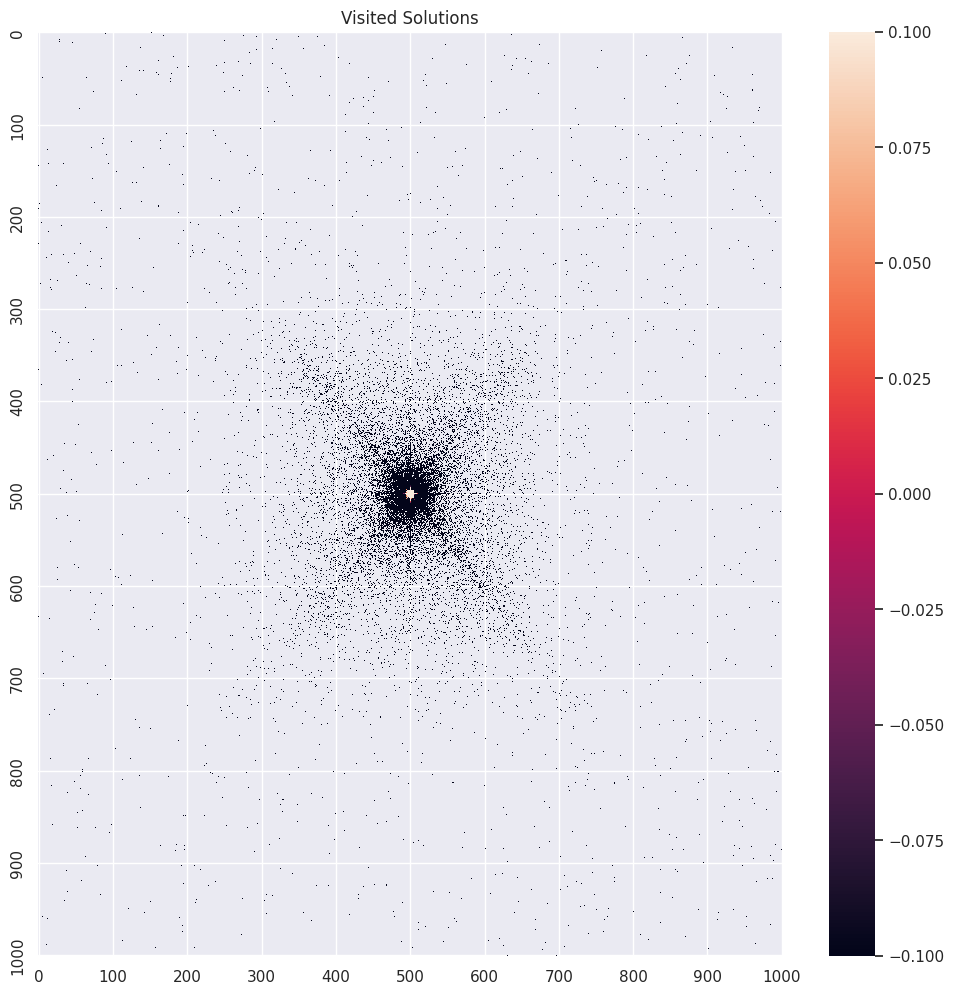

In [428]:
sns.set(rc = {'figure.figsize':(12,12)})
fig, ax = plt.subplots()
ax.set_xlabel('x')
ax.set_title('Visited Solutions')
ax.set_ylabel('y')
sns.heatmap(visited, xticklabels=100, yticklabels=100, ax=ax)

In [430]:
optimality_gaps = pd.DataFrame()

In [431]:
def read_csv(path: str, save_after: int):
    df = pd.read_csv(path, header=None)
    df.drop(df.columns[-1], axis=1, inplace=True)
    df = df.T
    df = df.reindex(df.index.repeat(save_after)).reset_index(drop=True)
    return df

In [432]:
def get_optimality_gap(df: pd.DataFrame, optimum: float):
    return df.mean(axis=1) - optimum

In [433]:
# get the newest file from folder which starts with two strings
def get_file(problem: str, algo: str):
    file_list = []
    for file in os.listdir(input_path):  #Add path
        if file.startswith(problem + '_' + algo + '_1'):
            file_list.append(file)
    file_list.sort()
    return file_list[-1]

In [434]:
psomab_ackley_df = read_csv(input_path + get_file('ackley', 'psomab'), 50)
optimality_gaps['psomab'] = get_optimality_gap(psomab_ackley_df, 0)

In [435]:
psoan_ackley_df = read_csv(input_path + get_file('ackley', 'psoan'), 50)
optimality_gaps['psoan'] = get_optimality_gap(psoan_ackley_df, 0)

In [436]:
lapso_ackley_df = read_csv(input_path + get_file('ackley', 'lapso'), 50)
optimality_gaps['lapso'] = get_optimality_gap(lapso_ackley_df, 0)

In [437]:
ocbaa_ackley_df = read_csv(input_path + get_file('ackley', 'psoocbaa'), 50)
optimality_gaps['ocbaa'] = get_optimality_gap(ocbaa_ackley_df, 0)

In [438]:
pso_ackley_df = read_csv(input_path + get_file('ackley', 'pso'), 50)
optimality_gaps['pso'] = get_optimality_gap(pso_ackley_df, 0)

In [439]:
psogd_ackley_df = read_csv(input_path + get_file('ackley', 'psogd'), 50)
optimality_gaps['psogd'] = get_optimality_gap(psogd_ackley_df, 0)

In [440]:
psoern_ackley_df = read_csv(input_path + get_file('ackley', 'psoern'), 50)
optimality_gaps['psoern'] = get_optimality_gap(psoern_ackley_df, 0)

<Axes: title={'center': 'Optimality gap of Algorithms on the Ackley function'}, xlabel='Evaluations of the objective function', ylabel='Optimality gap'>

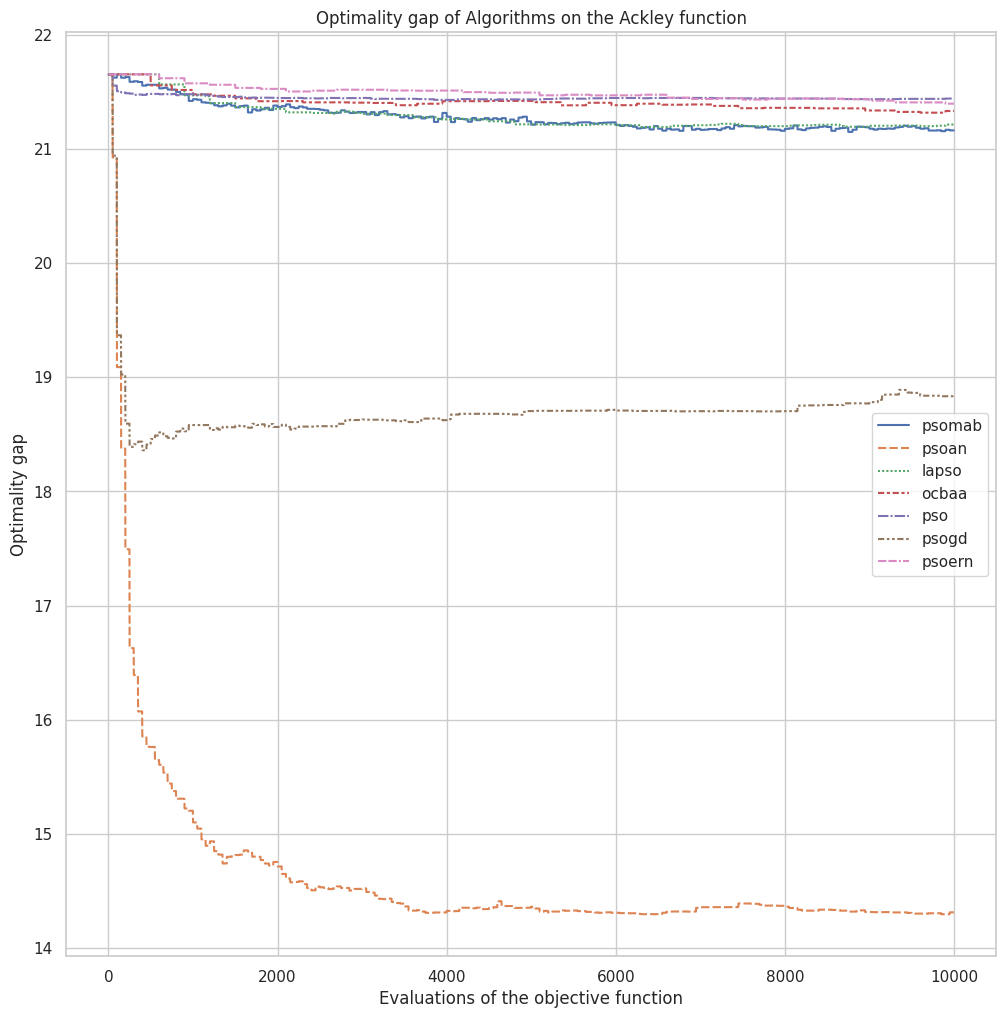

In [441]:
sns.set(rc = {'figure.figsize':(12,12)})
sns.set_style('whitegrid')
fig, ax = plt.subplots()
ax.set_xlabel('Evaluations of the objective function')
ax.set_title('Optimality gap of Algorithms on the Ackley function')
ax.set_ylabel('Optimality gap')
sns.lineplot(data=optimality_gaps, ax=ax)

In [406]:
best_values = pd.DataFrame()

In [407]:
def get_best_values(df: pd.DataFrame, optimum: float):
    return df.iloc[-1] - optimum

In [419]:
best_values['psomab'] = get_best_values(psomab_ackley_df, 0)
best_values['psoan'] = get_best_values(psoan_ackley_df, 0)
best_values['lapso'] = get_best_values(lapso_ackley_df, 0)
best_values['ocbaa'] = get_best_values(ocbaa_ackley_df, 0)
best_values['pso'] = get_best_values(pso_ackley_df, 0)
best_values['psogd'] = get_best_values(psogd_ackley_df, 0)
best_values['psoern'] = get_best_values(psoern_ackley_df, 0)

<Axes: title={'center': 'Optimality gap of Algorithms on the Ackley function'}, xlabel='Algorithms', ylabel='Optimality gap'>

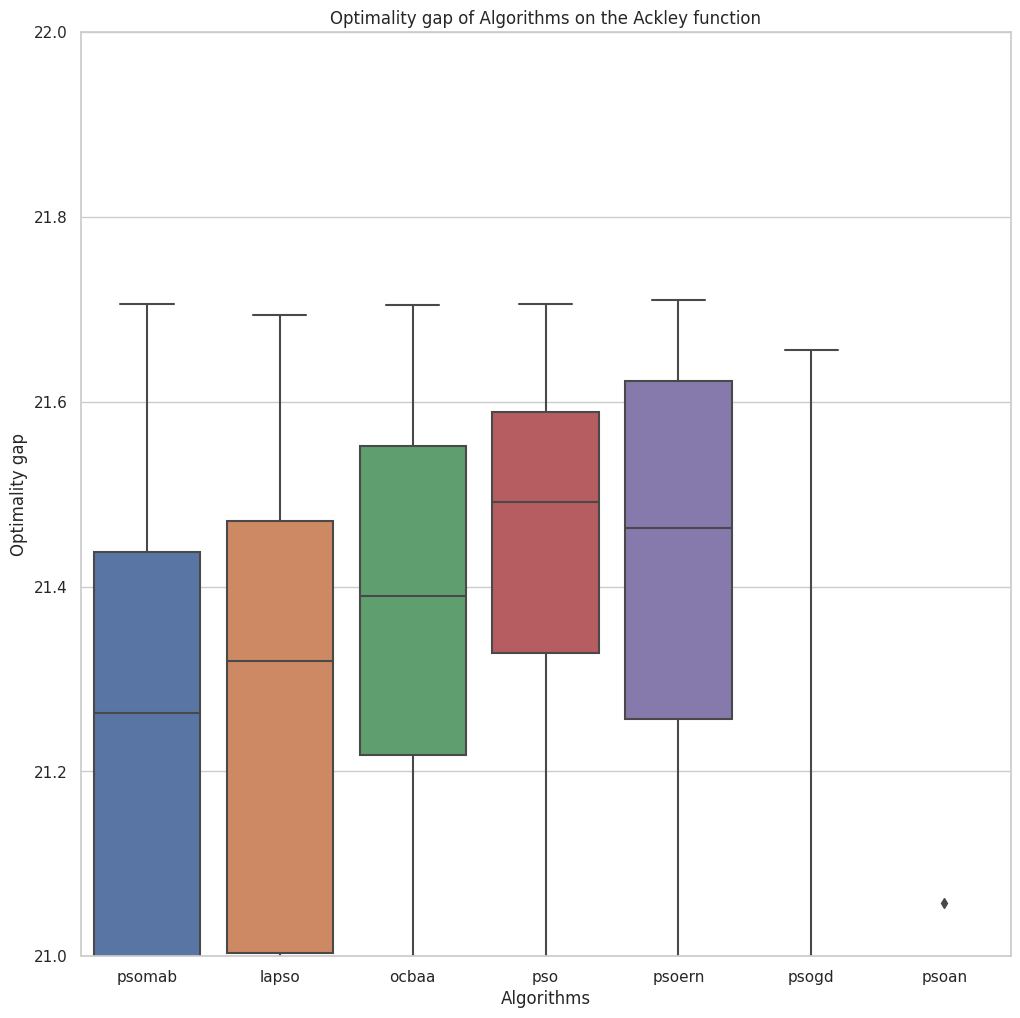

In [429]:
sns.set(rc = {'figure.figsize':(12,12)})
sns.set_style('whitegrid')
_, ax = plt.subplots()
ax.set_xlabel('Algorithms')
ax.set_title('Optimality gap of Algorithms on the Ackley function')
ax.set_ylabel('Optimality gap')
sns.boxplot(data=best_values, ax=ax)